# ЛР №5. "Обучение без учителя. Задача кластеризации"

## Генерация и загрузка датасетов

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs, make_classification

In [10]:
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, n_features=2, cluster_std=0.60, random_state=777)

X_class, y_class = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, n_classes=3, class_sep=2.0, random_state=777)

In [11]:
my_df = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv', encoding="utf-8", index_col=0)

In [12]:
X_real = my_df.drop(columns=['Fire Alarm'])
y_real = my_df['Fire Alarm']

## Рещение задачи кластеризации

In [13]:
from sklearn.datasets import make_blobs, make_classification
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, v_measure_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

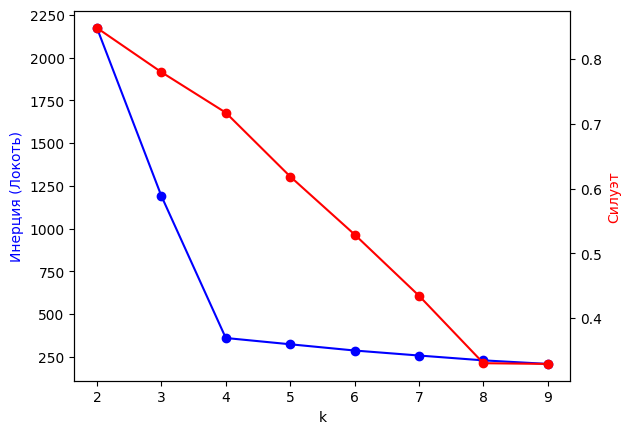

In [14]:
def find_k(X):
    inertia = []
    sil = []
    k_range = range(2, 10)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(X, km.labels_))
    
    fig, ax1 = plt.subplots()
    ax1.plot(k_range, inertia, 'bo-')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Инерция (Локоть)', color='b')
    ax2 = ax1.twinx()
    ax2.plot(k_range, sil, 'ro-')
    ax2.set_ylabel('Силуэт', color='r')
    plt.show()

find_k(X_blobs) 

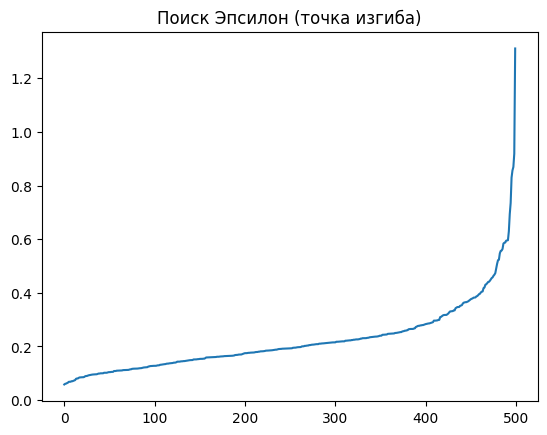

In [15]:
def find_epsilon(X):
    neigh = NearestNeighbors(n_neighbors=4)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)
    distances = np.sort(distances[:, 3], axis=0)
    plt.plot(distances)
    plt.title("Поиск Эпсилон (точка изгиба)")
    plt.show()

find_epsilon(X_blobs)


--- Анализ датасета: Blobs ---


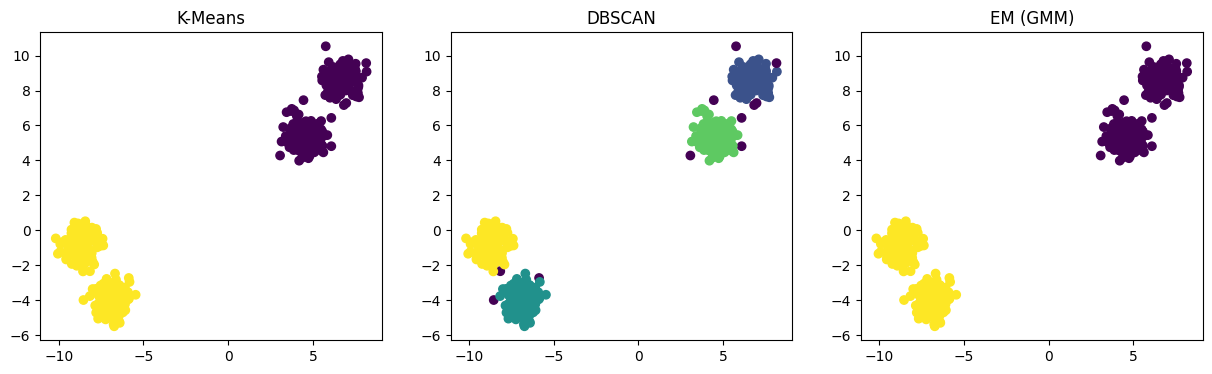

[K-Means]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[DBSCAN]: Sil=0.69, Cal=4302.4 | ARI=0.97, V-m=0.95
[EM-GMM]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[Agglomerative]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[AffinityProp]: Sil=0.72, Cal=16302.5 | ARI=1.00, V-m=1.00

--- Анализ датасета: Classification ---


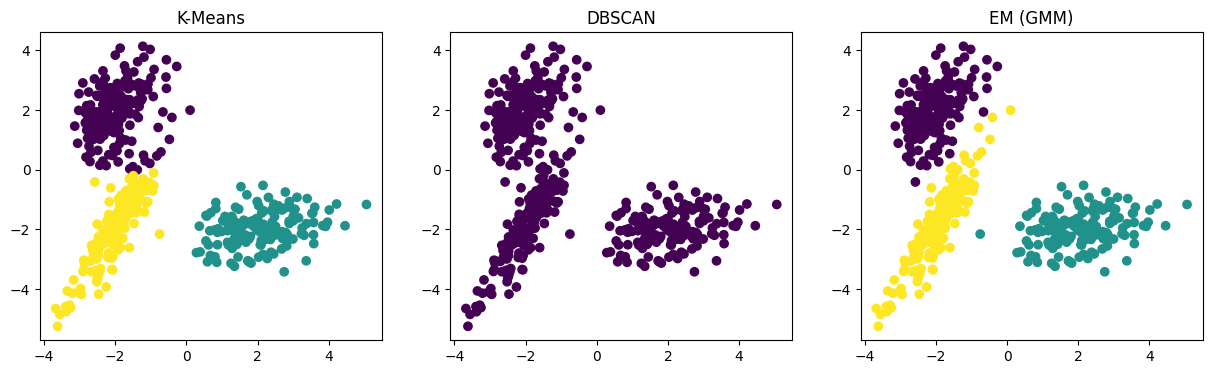

[K-Means]: Sil=0.64, Cal=1360.0 | ARI=0.90, V-m=0.88
[DBSCAN]: Кластеризация не удалась (1 кластер или только шум)
[EM-GMM]: Sil=0.62, Cal=1199.0 | ARI=0.98, V-m=0.97
[Agglomerative]: Sil=0.64, Cal=1318.0 | ARI=0.95, V-m=0.92
[AffinityProp]: Sil=0.36, Cal=1153.0 | ARI=0.31, V-m=0.58

--- Анализ датасета: Real Data ---


In [ ]:
from sklearn.preprocessing import StandardScaler

datasets = [("Blobs", X_blobs, y_blobs), 
            ("Classification", X_class, y_class), 
            ("Real Data", X_real, y_real)]

scaler = StandardScaler()

for name, X_raw, y_true in datasets:
    # Применяем StandardScaler только для Real Data
    if name == "Real Data":
        X = scaler.fit_transform(X_raw)
    else:
        X = X_raw
        
    print(f"\n--- Анализ датасета: {name} ---")
    
    k = 2 if name == "Blobs" else 3
    
    # 1. K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    
    # 2. DBSCAN (подберите eps по графику колена для каждого X)
    current_eps = 0.3 if name == "Real Data" else (0.5 if name == "Blobs" else 1.5)
    db = DBSCAN(eps=current_eps, min_samples=5).fit(X)
    
    # 3. EM-алгоритм (GMM)
    gm_labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X)
    
    # 4. Иерархическая кластеризация
    hc_labels = AgglomerativeClustering(n_clusters=k).fit_predict(X)
    
    # 5. Affinity Propagation
    ap = AffinityPropagation(damping=0.9, random_state=42).fit(X)
    ap_labels = ap.labels_

    # Словарь для итерации по результатам и оценки
    results = {
        "K-Means": km.labels_,
        "DBSCAN": db.labels_,
        "EM-GMM": gm_labels,
        "Agglomerative": hc_labels,
        "AffinityProp": ap_labels
    }

    # Визуализация синтетики (первые 3 метода)
    if name != "Real Data":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].scatter(X[:,0], X[:,1], c=km.labels_, cmap='viridis'); axes[0].set_title('K-Means')
        axes[1].scatter(X[:,0], X[:,1], c=db.labels_, cmap='viridis'); axes[1].set_title('DBSCAN')
        axes[2].scatter(X[:,0], X[:,1], c=gm_labels, cmap='viridis'); axes[2].set_title('EM (GMM)')
        plt.show()

    # Оценка качества для каждого алгоритма
    for algo_name, labels in results.items():
        # Проверка: DBSCAN может выдать только 1 кластер (шум), силуэт в этом случае не считается
        if len(set(labels)) > 1:
            sil = silhouette_score(X, labels)
            cal = calinski_harabasz_score(X, labels)
            ari = adjusted_rand_score(y_true, labels)
            vm = v_measure_score(y_true, labels)
            print(f"[{algo_name}]: Sil={sil:.2f}, Cal={cal:.1f} | ARI={ari:.2f}, V-m={vm:.2f}")
        else:
            print(f"[{algo_name}]: Кластеризация не удалась (1 кластер или только шум)")